<a href="https://colab.research.google.com/github/4GeeksAcademy/Wiston_Travieso_Proyecto-Tutorial-de-Clasficador-de-Imagenes/blob/main/Sistema%20de%20clasificaci%C3%B3n%20de%20im%C3%A1genes.es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Sistema de clasificación de imágenes

El conjunto de datos se compone de fotos de perros y gatos proporcionadas como un subconjunto de fotos de uno mucho más grande de 3 millones de fotos anotadas manualmente. Estos datos se obtuvieron a través de una colaboración entre Petfinder.com y Microsoft.

El conjunto de datos se usó originalmente como un CAPTCHA, es decir, una tarea que se cree que un humano encuentra trivial, pero que una máquina no puede resolver, que se usa en sitios web para distinguir entre usuarios humanos y bots. La tarea se denominó "Asirra". Cuando se presentó "Asirra", se mencionó "que los estudios de usuarios indican que los humanos pueden resolverlo el 99,6% de las veces en menos de 30 segundos". A menos que se produzca un gran avance en la visión artificial, esperamos que los ordenadores no tengan más de 1/54.000 posibilidades de resolverlo.

En el momento en que se publicó la competencia, el resultado de última generación se logró con un SVM y se describió en un artículo de 2007 con el título "Ataques de Machine Learning contra el CAPTCHA de Asirra" (PDF) que logró una precisión de clasificación del 80%. Fue este documento el que demostró que la tarea ya no era una tarea adecuada para un CAPTCHA poco después de que se propusiera la tarea.

In [1]:
# Importar Librerías

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import zipfile
from tensorflow import keras
from keras.preprocessing import image


I0000 00:00:1773947855.365456   27102 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773947857.105510   27102 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773947860.964521   27102 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


#### Paso 1: Carga del conjunto de datos

El conjunto de datos se encuentra en este link. Descarga la carpeta y descomprime los archivos. Ahora tendrás una carpeta con el dataset y una carpeta llamada train que contiene más de 25.000 archivos de imagen (formato .jpg) de perros y gatos. Las fotos están etiquetadas por su nombre de archivo, con la palabra dog o cat.

In [2]:
data = "/workspaces/Wiston_Travieso_Proyecto-Tutorial-de-Clasficador-de-Imagenes/data/raw/dogs-vs-cats.zip"

# Extraer las imágenes del archivo zip
with zipfile.ZipFile(data, 'r') as zip_ref:
    zip_ref.extractall("/workspaces/Wiston_Travieso_Proyecto-Tutorial-de-Clasficador-de-Imagenes/data/raw/dogs-vs-cats/")

KeyboardInterrupt: 

Paso 2: Visualiza la información de entrada

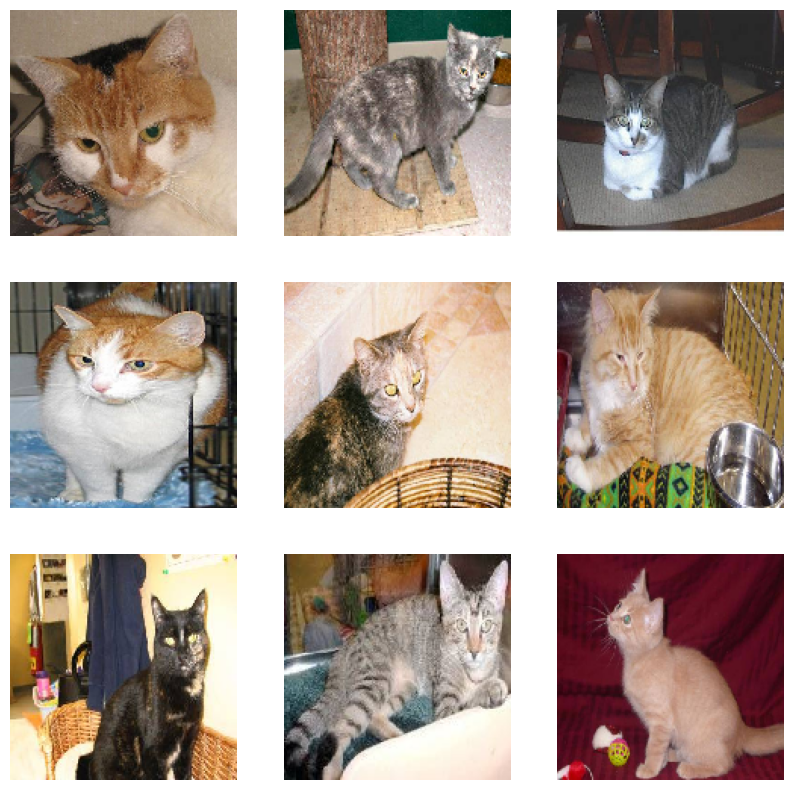

In [3]:
# Ruta al directorio que contiene sus datos de imagen

data_dir = "/workspaces/Wiston_Travieso_Proyecto-Tutorial-de-Clasficador-de-Imagenes/data/raw/dogs-vs-cats/dogs-vs-cats/train"

# Listar todos los archivos en la carpeta train
all_files = os.listdir(data_dir)

# Filtrar solo los que contienen la palabra 'cat'
cats_images_files = [f for f in all_files if f.startswith('cat')]

# Mostrar 9 imagenes de gatos

cats_images=[]
for i in range(9):
    img_path = os.path.join(data_dir, cats_images_files[i])
    img = image.load_img(img_path, target_size=(150, 150))
    cats_images.append(img)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(cats_images[i])
    plt.axis('off')
plt.show()

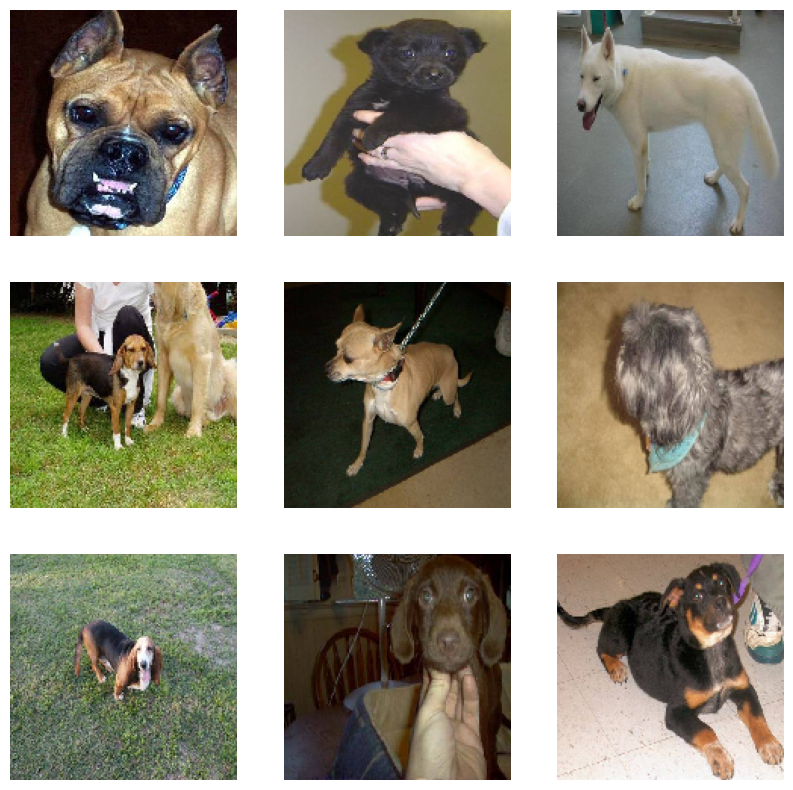

In [4]:
# Importar y comprobar 9 imagenes de perros

# Listar todos los archivos en la carpeta train
all_files = os.listdir(data_dir)

# 2. Filtrar solo los que contienen la palabra 'dog'
dogs_images_files = [f for f in all_files if f.startswith('dog')]

# Mostrar 9 imagenes de perros

dogs_images=[]
for i in range(9):
    img_path = os.path.join(data_dir, dogs_images_files[i])
    img = image.load_img(img_path, target_size=(150, 150))
    dogs_images.append(img)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(dogs_images[i])
    plt.axis('off')
plt.show()

In [6]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Crear lista de archivos y etiquetas
filenames = os.listdir(train_dir)
categories = []
for name in filenames:
    category = name.split('.')[0] # Extrae 'cat' o 'dog' del nombre 'cat.1.jpg'
    categories.append(category)

df = pd.DataFrame({
    'filename': filenames,
    'category': categories
})

# 2. Dividir en 80% entrenamiento y 20% validación
train_df, validate_df = train_test_split(df, test_size=0.20, random_state=42)

# 3. Configurar los generadores
datagen = ImageDataGenerator(rescale=1./255) # Normaliza los píxeles de 0-255 a 0-1

train_data = datagen.flow_from_dataframe(
    train_df, 
    directory=train_dir,
    x_col='filename',
    y_col='category',
    target_size=(200, 200),
    class_mode='binary',
    batch_size=32
)

test_data = datagen.flow_from_dataframe(
    validate_df, 
    directory=train_dir,
    x_col='filename',
    y_col='category',
    target_size=(200, 200),
    class_mode='binary',
    batch_size=32
)


Found 20000 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


Entrenar modelo

In [2]:
# Mover los datos a traves de la red

from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense  

model = Sequential()
model.add(Conv2D(input_shape = (224,224,3), filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 64,kernel_size = (3,3),padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Flatten())
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 2, activation = "softmax"))

I0000 00:00:1773948259.213858   28947 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773948261.286949   28947 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773948265.720921   28947 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/vscode/.local/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773948270.413293   28947 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error:

: 

In [ ]:
# Compilar el modelo con Adam
from keras.optimizers import Adam

model.compile(loss= keras.losses.categorical_crossentropy, optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

In [1]:
# Entrinar el modelo
model.fit(train_data, epochs=1)

NameError: name 'model' is not defined

Guarda el modelo

from keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("../models/vgg16_1.h5", monitor = "val_accuracy", verbose = 1, save_best_only = True, save_weights_only = False, mode = "auto")
early = EarlyStopping(monitor = "val_accuracy", patience = 3, verbose = 1, mode = "auto")
hist = model.fit(train_data, steps_per_epoch = 100, validation_data = test_data, validation_steps = 10, epochs = 3, callbacks = [checkpoint, early])

In [ ]:
# Comprobar la exactitud de los datos

# Trazar los resultados
plt.plot(hist.history["accuracy"])
plt.plot(hist.history["val_accuracy"])
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])

# Configurar el diseño del gráfico
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy", "Validation Accuracy", "Loss", "Validation Loss"])

# Trazar
plt.show()

In [ ]:
from keras.preprocessing import image
from keras.models import load_model

img = image.load_img("../data/raw/test/9.jpg", target_size = (200, 200))
img = np.asarray(img)
plt.imshow(img)
img = np.expand_dims(img, axis = 0)
saved_model = load_model("../models/vgg16_1.h5")
output = saved_model.predict(img)
if output[0][0] > output[0][1]:
    print("cat")
else:
    print("dog")